In [8]:
from sklearn.model_selection import learning_curve  #可视化学习的过程
from sklearn.datasets import load_digits  #数字data
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

例行导入各模块（学习曲线，数据集导入，SVM和绘图与数据）No module named 'sklearn.learning_curve',已被除名，修改为model_selection即可

In [9]:
digits=load_digits()
X=digits.data
Y=digits.target
train_sizes,train_loss,test_loss=learning_curve(
    SVC(gamma=0.001),X,Y,cv=10,scoring='neg_mean_squared_error',train_sizes=[0.1,0.25,0.5,0.75,1])
train_loss_mean=-np.mean(train_loss,axis=1)
test_loss_mean=-np.mean(test_loss,axis=1)

learning_curve自动用不同大小的训练集训练模型，并计算每种情况下的训练误差和验证误差，SVC是所用model，gamma是RBF核的gamma参数（越大拟合越快，但也容易过拟合），train_sizes表示每次训练使用多少比例的数据，在每个点记录一下，每次训练都返回loss；然后对所有loss取平均
axis=0：消掉行 → 每列剩一个值（沿着行方向按列计算）
axis=1：消掉列 → 每行剩一个值（沿着列方向按行计算）

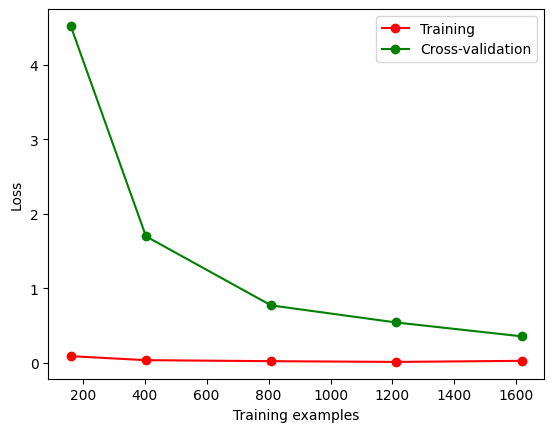

In [10]:
plt.plot(train_sizes,train_loss_mean,'o-',color='r',label='Training')
plt.plot(train_sizes,test_loss_mean,'o-',color='g',label='Cross-validation')
plt.xlabel('Training examples')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

可视化，一个画训练集loss平均，一个画测试集loss平均;加标签和图例